In [1]:
import sys
import os
sys.path.append(os.path.abspath('../server'))
import src.config as config
import src.data_utils as data_utils
from src.models import AttentionLayer

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import to_categorical
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import noisereduce as nr
import cv2
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SR = config.SR
DURATION = config.DURATION
IMG_SIZE = config.IMG_SIZE
BATCH_SIZE = config.BATCH_SIZE
CATEGORIES = config.CATEGORIES

CAT_DB_ROOT = Path(config.EXPERT_POOL_1)
CAT_SAMPLES_ROOT = Path(config.EXPERT_POOL_2)
ARCHIVE_ROOT = Path(config.VOCAL_ARCHIVE)

print(f'Using TensorFlow: {tf.__version__}')

Using TensorFlow: 2.21.0


In [3]:
def get_audio_files(root_dir):
    files = []
    for cat in CATEGORIES:
        p = root_dir / cat
        if p.exists():
            exts = ['*.mp3', '*.wav']
            for ext in exts:
                for f in p.glob(ext):
                    files.append({'path': str(f), 'label': cat})
    return files

expert_files = get_audio_files(CAT_DB_ROOT) + get_audio_files(CAT_SAMPLES_ROOT)
df_expert = pd.DataFrame(expert_files)
print(f"Expert samples for labeling: {len(df_expert)}")

def preprocess_expert(path):
    y, _ = librosa.load(path, sr=SR)
    y = nr.reduce_noise(y=y, sr=SR, prop_decrease=0.7)
    y = librosa.util.normalize(y)
    t_len = int(SR * DURATION)
    y = np.pad(y, (0, max(0, t_len - len(y))), mode='constant')[:t_len]

    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=128)
    mel = cv2.resize(librosa.power_to_db(mel), IMG_SIZE)
    mfcc = cv2.resize(librosa.feature.mfcc(y=y, sr=SR, n_mfcc=40), IMG_SIZE)

    def norm(a): return (a - a.min()) / (a.max() - a.min() + 1e-8)
    return np.stack([norm(mel), norm(mel), norm(mfcc)], axis=-1)

print("Processing expert features...")
X_exp, Y_exp = [], []
for _, row in tqdm(df_expert.iterrows(), total=len(df_expert)):
    try:
        feat = preprocess_expert(row['path'])
        X_exp.append(feat)
        Y_exp.append(row['label'])
        X_exp.append(feat + np.random.normal(0, 0.01, feat.shape))
        Y_exp.append(row['label'])
    except: continue

X_exp = np.array(X_exp, dtype=np.float32)
le = LabelEncoder()
Y_exp_enc = to_categorical(le.fit_transform(Y_exp))

base = MobileNetV2(input_shape=(128,128,3), include_top=False, weights='imagenet')
x = layers.GlobalAveragePooling2D()(base.output)
x = layers.Dense(128, activation='relu')(x)
out = layers.Dense(len(CATEGORIES), activation='softmax')(x)
labeler = Model(base.input, out)
labeler.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
labeler.fit(X_exp, Y_exp_enc, epochs=10, verbose=0)
print("Expert Labeler Ready.")

Expert samples for labeling: 150
Processing expert features...


100%|██████████| 150/150 [00:11<00:00, 13.50it/s]


Expert Labeler Ready.


In [4]:
archive_paths = list((ARCHIVE_ROOT/'dataset'/'dataset').glob('*.wav')) + \
                list((ARCHIVE_ROOT/'extras'/'other_vocalizations').glob('*.wav')) + \
                list((ARCHIVE_ROOT/'extras'/'sequences').glob('*.wav'))

print(f"Analyzing {len(archive_paths)} files from audio_vault...")
re_labeled_data = []

for path in tqdm(archive_paths):
    try:
        feat = preprocess_expert(str(path))
        pred = labeler.predict(np.expand_dims(feat, 0), verbose=0)
        new_label = le.classes_[np.argmax(pred)]
        re_labeled_data.append({'path': str(path), 'label': new_label})
    except: continue

df_final = pd.DataFrame(re_labeled_data)
print("\nNewly Mapped 10-Class Labels for audio vault:")
print(df_final['label'].value_counts())
df_final.head()

Analyzing 483 files from audio_vault...


100%|██████████| 483/483 [00:22<00:00, 21.34it/s]


Newly Mapped 10-Class Labels for audio vault:
label
Fighting       282
MotherCall     193
HuntingMind      8
Name: count, dtype: int64


,path,label
0,/Users/ajay/project/datasets/audio_vault/datas...,Fighting
1,/Users/ajay/project/datasets/audio_vault/datas...,Fighting
2,/Users/ajay/project/datasets/audio_vault/datas...,MotherCall
3,/Users/ajay/project/datasets/audio_vault/datas...,MotherCall
4,/Users/ajay/project/datasets/audio_vault/datas...,Fighting


100%|██████████| 483/483 [00:07<00:00, 61.48it/s]


Training Production Model...
Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 22s 191ms/step - accuracy: 0.4731 - loss: 1.6614 - val_accuracy: 0.5741 - val_loss: 1.3645
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - accuracy: 0.7769 - loss: 0.6880 - val_accuracy: 0.5741 - val_loss: 1.2722
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - accuracy: 0.8574 - loss: 0.4302 - val_accuracy: 0.6296 - val_loss: 1.1861
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step - accuracy: 0.9050 - loss: 0.3317 - val_accuracy: 0.5000 - val_loss: 1.2348
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 0.9421 - loss: 0.2089 - val_accuracy: 0.4630 - val_loss: 1.2918
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - accuracy: 0.9153 - loss: 0.2173 - val_accuracy: 0.3519 - val_loss: 1.6052
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 0.9649 - loss: 0.1348 - val_accuracy: 0.5370 - val_loss: 1.1924
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step - accuracy: 0.9855 - l

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


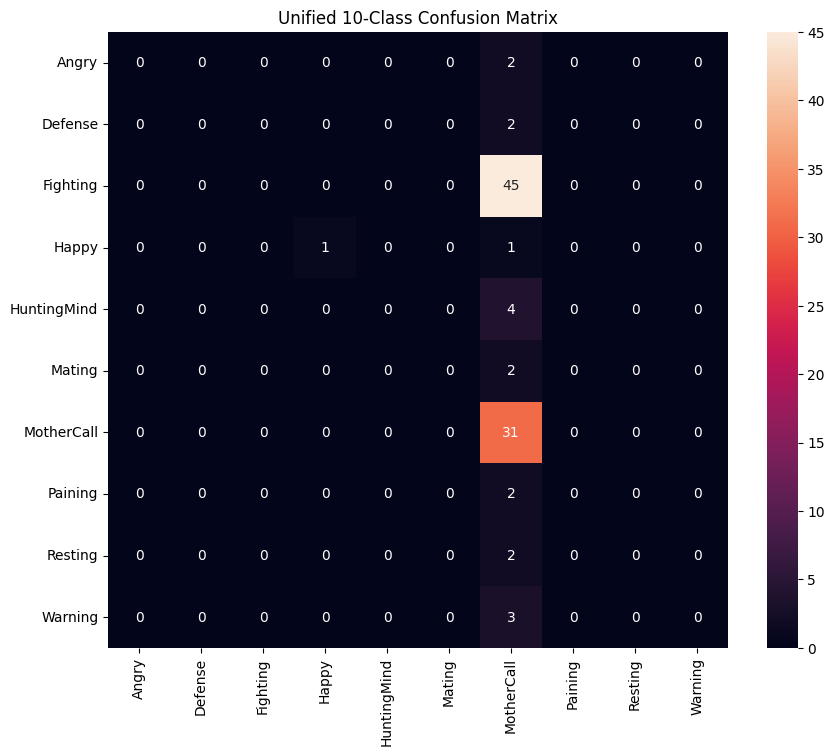

In [5]:
X_final, Y_final = [], []
for _, row in tqdm(df_final.iterrows(), total=len(df_final)):
    try:
        X_final.append(preprocess_expert(row['path']))
        Y_final.append(row['label'])
    except: continue

for _, row in df_expert.iterrows():
    X_final.append(preprocess_expert(row['path']))
    Y_final.append(row['label'])

X_final = np.array(X_final, dtype=np.float32)
Y_final_enc = to_categorical(le.transform(Y_final))

X_tr, X_te, y_tr, y_te = train_test_split(X_final, Y_final_enc, test_size=0.15, stratify=Y_final, random_state=42)

def build_prod_model():
    base = MobileNetV2(input_shape=(128,128,3), include_top=False, weights='imagenet')
    base.trainable = True
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(10, activation='softmax')(x)
    model = Model(base.input, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

final_model = build_prod_model()
print("Training Production Model...")
history = final_model.fit(X_tr, y_tr, epochs=30, batch_size=BATCH_SIZE, validation_split=0.1, verbose=1)

y_pred = final_model.predict(X_te).argmax(axis=1)
y_true = y_te.argmax(axis=1)
print("\nFinal Classification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Unified 10-Class Confusion Matrix")
plt.show()

In [6]:
def predict_cat_emotion(audio_path, model, label_encoder):
    """
    Unified Prediction Pipeline: Preprocesses and classifies cat audio.
    """
    print(f"--- Starting Inference Pipeline for: {os.path.basename(audio_path)} ---")

    print("[1/5] Loading and resampling to 22050Hz...")
    y, _ = librosa.load(audio_path, sr=SR)

    print("[2/5] Applying Spectral Gating (noisereduce)...")
    y = nr.reduce_noise(y=y, sr=SR, prop_decrease=0.7)

    print(f"[3/5] Standardizing duration to {DURATION}s and normalizing...")
    y = librosa.util.normalize(y)
    t_len = int(SR * DURATION)
    y = np.pad(y, (0, max(0, t_len - len(y))), mode='constant')[:t_len]

    print("[4/5] Extracting 3-channel spectral features (Log-Mel + MFCC)...")
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=128)
    mel_db = cv2.resize(librosa.power_to_db(mel), IMG_SIZE)
    mfcc = cv2.resize(librosa.feature.mfcc(y=y, sr=SR, n_mfcc=40), IMG_SIZE)

    def norm(a): return (a - a.min()) / (a.max() - a.min() + 1e-8)
    mel_norm = norm(mel_db)
    mfcc_norm = norm(mfcc)
    feat = np.stack([mel_norm, mel_norm, mfcc_norm], axis=-1)

    print("[5/5] Running model inference...")
    pred = model.predict(np.expand_dims(feat, 0), verbose=0)
    class_idx = np.argmax(pred)
    confidence = np.max(pred) * 100
    label = label_encoder.classes_[class_idx]

    # Display input features
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 3, 1)
    librosa.display.specshow(mel_db, x_axis='time', y_axis='mel')
    plt.title("Mel Spectrogram")
    plt.colorbar()

    plt.subplot(2, 3, 2)
    plt.imshow(mel_norm, cmap='viridis', aspect='auto')
    plt.title("Normalized Mel")
    plt.colorbar()

    plt.subplot(2, 3, 3)
    plt.imshow(mfcc_norm, cmap='plasma', aspect='auto')
    plt.title("Normalized MFCC")
    plt.colorbar()

    plt.subplot(2, 3, 4)
    plt.imshow(feat[:, :, 0], cmap='viridis', aspect='auto')
    plt.title("Channel 1 (Mel)")

    plt.subplot(2, 3, 5)
    plt.imshow(feat[:, :, 1], cmap='viridis', aspect='auto')
    plt.title("Channel 2 (Mel)")

    plt.subplot(2, 3, 6)
    plt.imshow(feat[:, :, 2], cmap='plasma', aspect='auto')
    plt.title("Channel 3 (MFCC)")

    plt.tight_layout()
    plt.show()

    # Original plots
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    librosa.display.specshow(mel_db, x_axis='time', y_axis='mel')
    plt.title(f"Spectrogram: {label}")

    plt.subplot(1, 2, 2)
    sns.barplot(x=pred[0], y=list(label_encoder.classes_), palette='viridis')
    plt.title("Class Probabilities")
    plt.xlim(0, 1)

    plt.tight_layout()
    plt.show()

    print(f"\nFINAL RESULT: {label.upper()}")
    print(f"CONFIDENCE: {confidence:.2f}%")

    print("\n--- Emotion Breakdown ---")
    sorted_probs = sorted(zip(CATEGORIES, pred[0]), key=lambda x: x[1], reverse=True)
    for cat, prob in sorted_probs:
        print(f"{cat:12}: {prob*100:6.2f}%")
    return label

Testing on: /Users/ajay/project/datasets/expert_collection_2/Fighting/car_extcoll0136.mp3
--- Starting Inference Pipeline for: car_extcoll0136.mp3 ---
[1/5] Loading and resampling to 22050Hz...
[2/5] Applying Spectral Gating (noisereduce)...
[3/5] Standardizing duration to 3.0s and normalizing...
[4/5] Extracting 3-channel spectral features (Log-Mel + MFCC)...
[5/5] Running model inference...


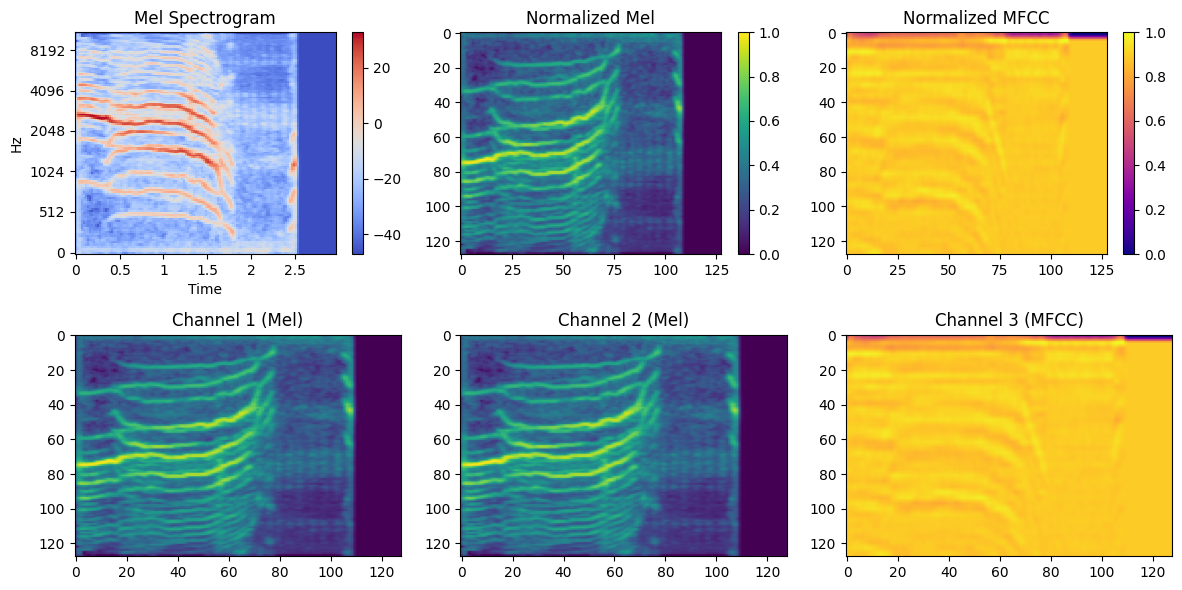

/var/folders/s7/yc1pvgjd40v4n0v3bj6kpp7w0000gn/T/ipykernel_18275/1351081078.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pred[0], y=list(label_encoder.classes_), palette='viridis')


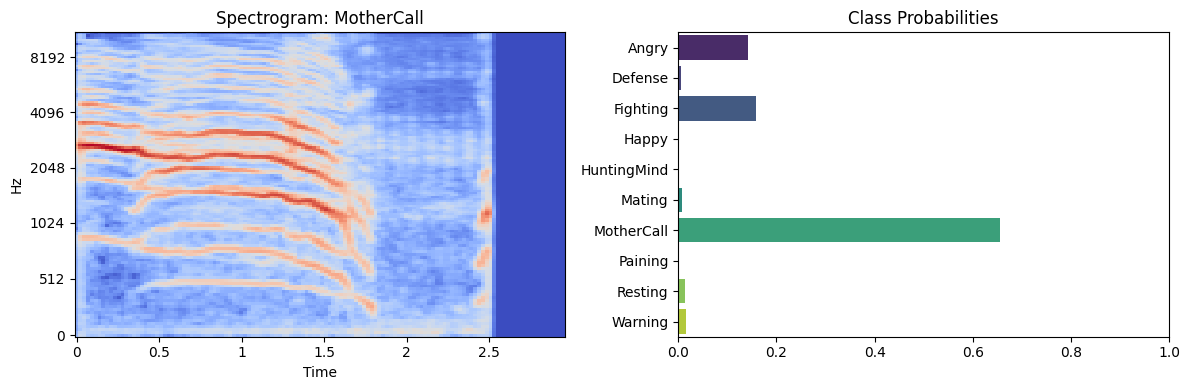


FINAL RESULT: MOTHERCALL
CONFIDENCE: 65.51%

--- Emotion Breakdown ---
MotherCall  :  65.51%
Fighting    :  15.92%
Angry       :  14.14%
Resting     :   1.28%
Mating      :   0.70%
Defense     :   0.62%
Paining     :   0.19%
Happy       :   0.14%
HuntingMind :   0.02%


np.str_('MotherCall')

In [7]:
test_file = df_expert.sample(1)['path'].values[0]
print(f"Testing on: {test_file}")

predict_cat_emotion(test_file, final_model, le)

In [8]:
import os
import src.config as config
# Use a static test file path for automated verification
user_audio_path = os.path.join(config.EXPERT_POOL_1, 'Angry', 'car_extcoll0103.mp3')

if os.path.exists(user_audio_path):
    print(f'Running inference on: {user_audio_path}')
    predict_cat_emotion(user_audio_path, final_model, le)
else:
    print(f'Test file not found at: {user_audio_path}')

Test file not found at: /Users/ajay/project/datasets/expert_collection_1/Angry/car_extcoll0103.mp3


Running inference on: /Users/ajay/project/datasets/expert_collection_2/Angry/car_extcoll0128.mp3
--- Starting Inference Pipeline for: car_extcoll0128.mp3 ---
[1/5] Loading and resampling to 22050Hz...
[2/5] Applying Spectral Gating (noisereduce)...
[3/5] Standardizing duration to 3.0s and normalizing...
[4/5] Extracting 3-channel spectral features (Log-Mel + MFCC)...
[5/5] Running model inference...


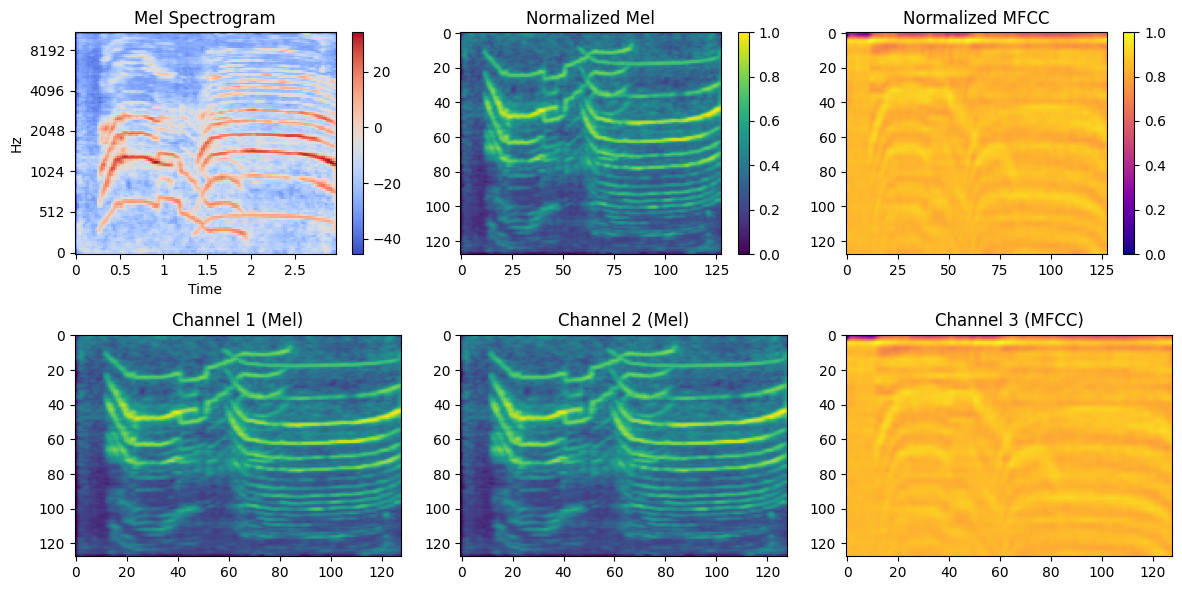

/var/folders/s7/yc1pvgjd40v4n0v3bj6kpp7w0000gn/T/ipykernel_18275/1351081078.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pred[0], y=list(label_encoder.classes_), palette='viridis')


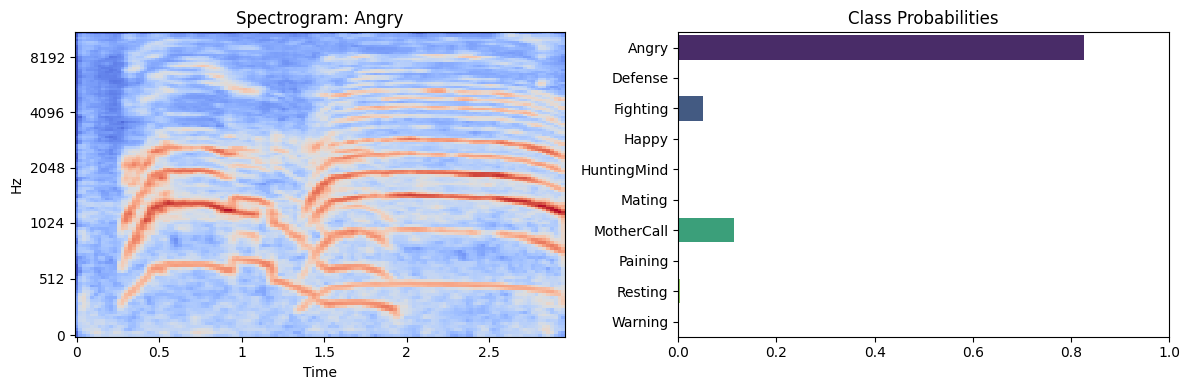


FINAL RESULT: ANGRY
CONFIDENCE: 82.63%

--- Emotion Breakdown ---
Angry       :  82.63%
MotherCall  :  11.43%
Fighting    :   5.10%
Resting     :   0.35%
Paining     :   0.18%
Mating      :   0.12%
Happy       :   0.02%
Defense     :   0.01%
HuntingMind :   0.00%


In [9]:
# User input for audio file path
user_audio_path = '/Users/ajay/project/datasets/expert_collection_2/Angry/car_extcoll0128.mp3'

if os.path.exists(user_audio_path):
    print(f'Running inference on: {user_audio_path}')
    predict_cat_emotion(user_audio_path, final_model, le)
else:
    print(f'File not found at: {user_audio_path}')
    print("Please check the path and try again.")

In [10]:

print("Evaluating model on test set...")
test_loss, test_accuracy = final_model.evaluate(X_te, y_te, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predict on a few test samples
print("\nTesting on a few random test samples:")
for i in range(5):
    idx = np.random.randint(0, len(X_te))
    sample = X_te[idx:idx+1]
    true_label = le.classes_[y_te[idx].argmax()]
    pred = final_model.predict(sample, verbose=0)
    pred_label = le.classes_[pred.argmax()]
    confidence = np.max(pred) * 100
    print(f"Sample {i+1}: True: {true_label}, Predicted: {pred_label}, Confidence: {confidence:.2f}%")

Evaluating model on test set...
Test Loss: 2.7969
Test Accuracy: 0.3368

Testing on a few random test samples:
Sample 1: True: Fighting, Predicted: MotherCall, Confidence: 95.92%
Sample 2: True: Fighting, Predicted: MotherCall, Confidence: 98.63%
Sample 3: True: MotherCall, Predicted: MotherCall, Confidence: 99.97%
Sample 4: True: MotherCall, Predicted: MotherCall, Confidence: 99.87%
Sample 5: True: Fighting, Predicted: MotherCall, Confidence: 71.43%
